# Bearing Fault Dataset Analysis

**Source**: Paderborn University KAT Datacenter

This notebook analyzes the bearing fault dataset to understand:
1. Multimodal sensor data structure
2. Physics groups for masking strategies
3. Fault type distributions
4. What a classifier could learn (analogous to Brain-JEPA pathology classification)

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy import signal
import json
from pathlib import Path

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 11

DATA_DIR = Path('../data/bearings')

## 1. Dataset Overview

In [21]:
# Load processed data
try:
    episodes_df = pd.read_parquet(DATA_DIR / 'bearing_episodes.parquet')
    windows_df = pd.read_parquet(DATA_DIR / 'bearing_windows.parquet')
    with open(DATA_DIR / 'statistics.json') as f:
        stats = json.load(f)
    
    print("Dataset Overview:")
    print(f"  Bearings: {stats['n_bearings']}")
    print(f"  Episodes: {stats['n_episodes']}")
    print(f"  Windows: {stats['n_windows']}")
    print(f"  Window size: {stats['window_size']}")
    print(f"\nFault Distribution:")
    for fault, count in stats['fault_distribution'].items():
        pct = count / stats['n_windows'] * 100
        print(f"  {fault}: {count:,} ({pct:.1f}%)")
except FileNotFoundError:
    print("Processed data not found. Using raw data for analysis.")
    episodes_df = None
    windows_df = None

Processed data not found. Using raw data for analysis.


## 2. Sensor Channel Structure

The Paderborn dataset has **8 channels** organized into **4 physics groups**:

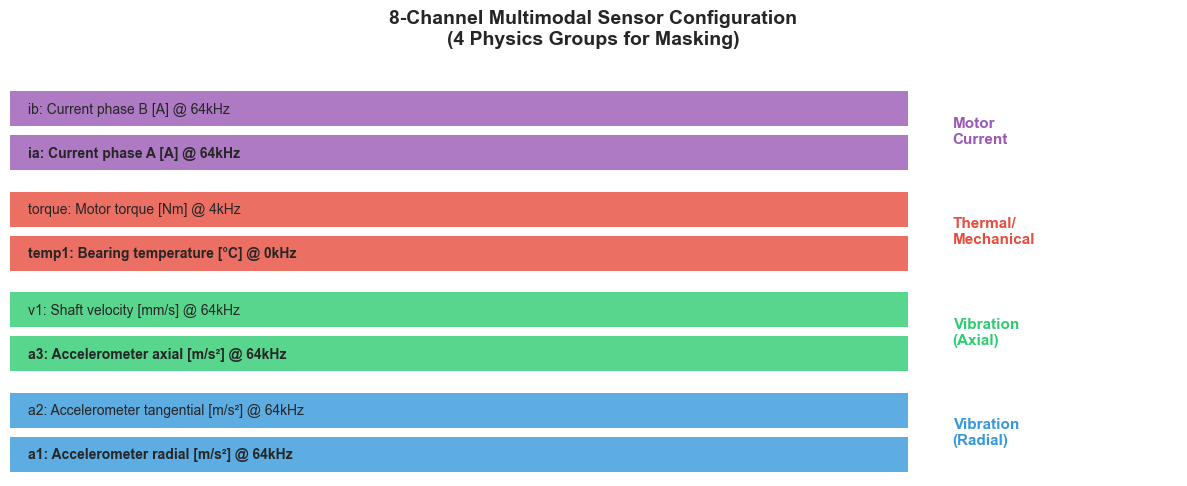

In [22]:
# Physics groups visualization
physics_groups = {
    'Vibration\n(Radial)': ['a1', 'a2'],
    'Vibration\n(Axial)': ['a3', 'v1'],
    'Thermal/\nMechanical': ['temp1', 'torque'],
    'Motor\nCurrent': ['ia', 'ib'],
}

channel_info = {
    'a1': ('Accelerometer radial', 'm/s²', 64000),
    'a2': ('Accelerometer tangential', 'm/s²', 64000),
    'a3': ('Accelerometer axial', 'm/s²', 64000),
    'v1': ('Shaft velocity', 'mm/s', 64000),
    'temp1': ('Bearing temperature', '°C', 1),
    'torque': ('Motor torque', 'Nm', 4000),
    'ia': ('Current phase A', 'A', 64000),
    'ib': ('Current phase B', 'A', 64000),
}

fig, ax = plt.subplots(figsize=(12, 5))

colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
y_positions = []
y = 0

for i, (group, channels) in enumerate(physics_groups.items()):
    for ch in channels:
        desc, unit, fs = channel_info[ch]
        ax.barh(y, 1, color=colors[i], alpha=0.8, height=0.8)
        ax.text(0.02, y, f'{ch}: {desc} [{unit}] @ {fs/1000:.0f}kHz', 
                va='center', fontsize=10, fontweight='bold' if ch in ['a1', 'a3', 'temp1', 'ia'] else 'normal')
        y_positions.append((y, group))
        y += 1
    y += 0.3  # Gap between groups

# Add group labels
for i, (group, _) in enumerate(physics_groups.items()):
    group_y = [yp for yp, g in y_positions if g == group]
    ax.text(1.05, np.mean(group_y), group, va='center', fontsize=11, fontweight='bold', color=colors[i])

ax.set_xlim(0, 1.3)
ax.set_ylim(-0.5, y)
ax.set_yticks([])
ax.set_xticks([])
ax.set_title('8-Channel Multimodal Sensor Configuration\n(4 Physics Groups for Masking)', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

## 3. Fault Type Distribution

In [19]:
if windows_df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Left: Fault type distribution
    ax = axes[0]
    fault_counts = windows_df['fault_type'].value_counts()
    colors = ['#2ecc71', '#e74c3c', '#3498db', '#9b59b6']
    bars = ax.bar(fault_counts.index, fault_counts.values, color=colors[:len(fault_counts)])
    ax.set_ylabel('Number of Windows')
    ax.set_title('Fault Type Distribution')
    for bar, val in zip(bars, fault_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
                f'{val:,}', ha='center', fontsize=10)
    
    # Right: Per-bearing distribution
    ax = axes[1]
    bearing_counts = windows_df.groupby(['bearing', 'fault_type']).size().unstack(fill_value=0)
    bearing_counts.plot(kind='bar', stacked=True, ax=ax, color=colors[:len(fault_counts)])
    ax.set_xlabel('Bearing')
    ax.set_ylabel('Windows')
    ax.set_title('Windows per Bearing')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Fault Type', loc='upper right')
    
    plt.tight_layout()
    plt.show()
else:
    print("Windows data not available. Run prepare_bearing_dataset.py --process first.")

Windows data not available. Run prepare_bearing_dataset.py --process first.


## 4. Example Signals by Fault Type

Visualize raw sensor signals for different fault conditions.

In [ ]:
# Load example raw data if available
raw_dir = DATA_DIR / 'raw'

def load_example_signal(bearing: str) -> np.ndarray:
    """Load first measurement from a bearing."""
    bearing_dir = raw_dir / bearing
    if not bearing_dir.exists():
        return None
    
    mat_files = list(bearing_dir.rglob('*.mat'))
    if not mat_files:
        return None
    
    try:
        data = loadmat(str(mat_files[0]), squeeze_me=True, struct_as_record=False)
        for key in data.keys():
            if not key.startswith('_'):
                val = data[key]
                if hasattr(val, 'Y'):
                    return val.Y[:, :8] if val.Y.ndim > 1 else None
                elif isinstance(val, np.ndarray) and val.ndim == 2:
                    return val[:, :8] if val.shape[1] >= 8 else val
    except Exception as e:
        print(f"Failed to load {bearing}: {e}")
    return None

# Try to load examples
examples = {
    'Healthy (K001)': load_example_signal('K001'),
    'Outer Race (KA01)': load_example_signal('KA01'),
    'Inner Race (KI01)': load_example_signal('KI01'),
}

# Filter out None values
examples = {k: v for k, v in examples.items() if v is not None}

if examples:
    fig, axes = plt.subplots(len(examples), 1, figsize=(14, 3*len(examples)))
    if len(examples) == 1:
        axes = [axes]
    
    fs = 64000  # Sampling rate
    n_samples = 10000  # Show first 10k samples (~0.15 sec)
    
    for ax, (label, data) in zip(axes, examples.items()):
        t = np.arange(min(n_samples, len(data))) / fs * 1000  # Time in ms
        
        # Plot vibration channel (a1 - radial accelerometer)
        ax.plot(t, data[:len(t), 0], linewidth=0.5, alpha=0.8)
        ax.set_ylabel('a1 (m/s²)')
        ax.set_title(f'{label} - Radial Vibration')
        ax.set_xlim(0, t[-1])
    
    axes[-1].set_xlabel('Time (ms)')
    plt.tight_layout()
    plt.show()
else:
    print("Raw data not available. Run prepare_bearing_dataset.py --download first.")

## 5. Frequency Analysis

Bearing faults often manifest as characteristic frequencies in vibration spectra.

In [ ]:
if examples:
    fig, axes = plt.subplots(len(examples), 1, figsize=(14, 3*len(examples)))
    if len(examples) == 1:
        axes = [axes]
    
    fs = 64000
    
    for ax, (label, data) in zip(axes, examples.items()):
        # Compute FFT
        x = data[:, 0]  # a1 channel
        freqs, psd = signal.welch(x, fs=fs, nperseg=4096)
        
        ax.semilogy(freqs, psd, linewidth=0.8)
        ax.set_ylabel('PSD')
        ax.set_title(f'{label} - Power Spectral Density')
        ax.set_xlim(0, 10000)  # Show up to 10 kHz
        ax.grid(True, alpha=0.3)
    
    axes[-1].set_xlabel('Frequency (Hz)')
    plt.tight_layout()
    plt.show()
else:
    print("Raw data not available for frequency analysis.")

## 6. Classification Task

**Analogous to Brain-JEPA**: What can a classifier learn from this data?

### Potential Tasks:
1. **Binary Fault Detection**: Healthy vs Faulty
2. **4-Class Fault Classification**: Healthy / Outer / Inner / Combined
3. **Severity Estimation**: If damage size metadata available
4. **RUL Prediction**: Remaining useful life (if run-to-failure data)

In [ ]:
if windows_df is not None:
    # Simple feature-based classification
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
    import seaborn as sns
    
    # Use RMS features from each channel
    feature_cols = [c for c in windows_df.columns if '_rms' in c or '_std' in c]
    
    if feature_cols:
        X = windows_df[feature_cols].values
        y = windows_df['fault_label'].values
        
        # Remove any NaN
        mask = ~np.isnan(X).any(axis=1)
        X, y = X[mask], y[mask]
        
        if len(X) > 100:
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
            
            clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)
            
            print("Random Forest: 4-Class Fault Classification")
            print("="*50)
            print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
            print(f"\nBaseline (majority): {max(np.bincount(y)) / len(y):.3f}")
            
            # Confusion matrix
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            
            ax = axes[0]
            cm = confusion_matrix(y_test, y_pred)
            labels = ['Healthy', 'Outer', 'Inner', 'Combined']
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                        xticklabels=labels[:len(cm)], yticklabels=labels[:len(cm)])
            ax.set_xlabel('Predicted')
            ax.set_ylabel('True')
            ax.set_title('Confusion Matrix')
            
            # Feature importance
            ax = axes[1]
            importance = clf.feature_importances_
            sorted_idx = np.argsort(importance)[::-1][:10]
            ax.barh(range(len(sorted_idx)), importance[sorted_idx], color='#3498db')
            ax.set_yticks(range(len(sorted_idx)))
            ax.set_yticklabels([feature_cols[i] for i in sorted_idx])
            ax.set_xlabel('Importance')
            ax.set_title('Top 10 Feature Importance')
            ax.invert_yaxis()
            
            plt.tight_layout()
            plt.show()
        else:
            print(f"Not enough samples for classification ({len(X)})")
    else:
        print("Feature columns not found in windows data.")
else:
    print("Windows data not available for classification.")

## 7. Summary

### Dataset Characteristics
| Property | Value |
|----------|-------|
| Bearings | 33 |
| Channels | 8 (multimodal) |
| Physics Groups | 4 |
| Sampling Rate | 64 kHz (vibration) |
| Fault Types | 4 (healthy, outer, inner, combined) |

### Physics Groups for Masking
| Group | Channels | Modality |
|-------|----------|----------|
| 1 | a1, a2 | Radial vibration |
| 2 | a3, v1 | Axial vibration |
| 3 | temp1, torque | Thermal/mechanical |
| 4 | ia, ib | Motor current |

### Comparison to Brain-JEPA
| Aspect | Brain-JEPA | Bearing Faults |
|--------|------------|----------------|
| Modality | fMRI voxels | 8-channel sensors |
| Physics groups | Brain regions | Sensor modalities |
| Samples | 2.3B tokens | ~1M samples |
| Diagnosis | Pathology | Fault type |
| Masking strategy | Region-aware | Physics-aware |